In [1]:
import pandas as pd
import numpy as np
import pickle

from torch.autograd import Variable
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader


import torch.utils.data as data_utils
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns
from pylab import rcParams

from sklearn.metrics import (confusion_matrix, precision_recall_curve, auc,
                             roc_curve, recall_score, AgeGroupification_report, f1_score,
                             precision_recall_fscore_support)

sns.set(style='whitegrid', palette='muted', font_scale=1.5)

rcParams['figure.figsize'] = 14, 8

RANDOM_SEED = 42
LABELS = ["молодой", "старый"]

In [2]:

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/abalone/abalone.data"
column_names = ['Sex', 'Length', 'Diameter', 'Height', 'Whole_weight',
                'Shucked_weight', 'Viscera_weight', 'Shell_weight', 'Rings']

df = pd.read_csv(url, names=column_names)

In [3]:
df.head(5)

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [4]:
print(df.shape)
print(df.describe())

(4177, 9)
            Length     Diameter       Height  Whole_weight  Shucked_weight  \
count  4177.000000  4177.000000  4177.000000   4177.000000     4177.000000   
mean      0.523992     0.407881     0.139516      0.828742        0.359367   
std       0.120093     0.099240     0.041827      0.490389        0.221963   
min       0.075000     0.055000     0.000000      0.002000        0.001000   
25%       0.450000     0.350000     0.115000      0.441500        0.186000   
50%       0.545000     0.425000     0.140000      0.799500        0.336000   
75%       0.615000     0.480000     0.165000      1.153000        0.502000   
max       0.815000     0.650000     1.130000      2.825500        1.488000   

       Viscera_weight  Shell_weight        Rings  
count     4177.000000   4177.000000  4177.000000  
mean         0.180594      0.238831     9.933684  
std          0.109614      0.139203     3.224169  
min          0.000500      0.001500     1.000000  
25%          0.093500      0.130

In [5]:
df.isnull().values.any()

np.False_

In [6]:
sex_mapping = {'M': 0, 'F': 1, 'I': 2}
df['Sex'] = df['Sex'].map(sex_mapping)

In [7]:
# Пример: бинарная классификация (молодые до 9 колец, взрослые 10+)
df['AgeGroup'] = (df['Rings'] >= 10).astype(int)
y = df['AgeGroup']
X = df.drop(['Rings', 'AgeGroup'], axis=1)


In [9]:
df['AgeGroup'].value_counts()

,count
AgeGroup,
0,2096
1,2081


/tmp/ipykernel_3610/1668154857.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  count_classes = pd.value_counts(df['AgeGroup'], sort = True)


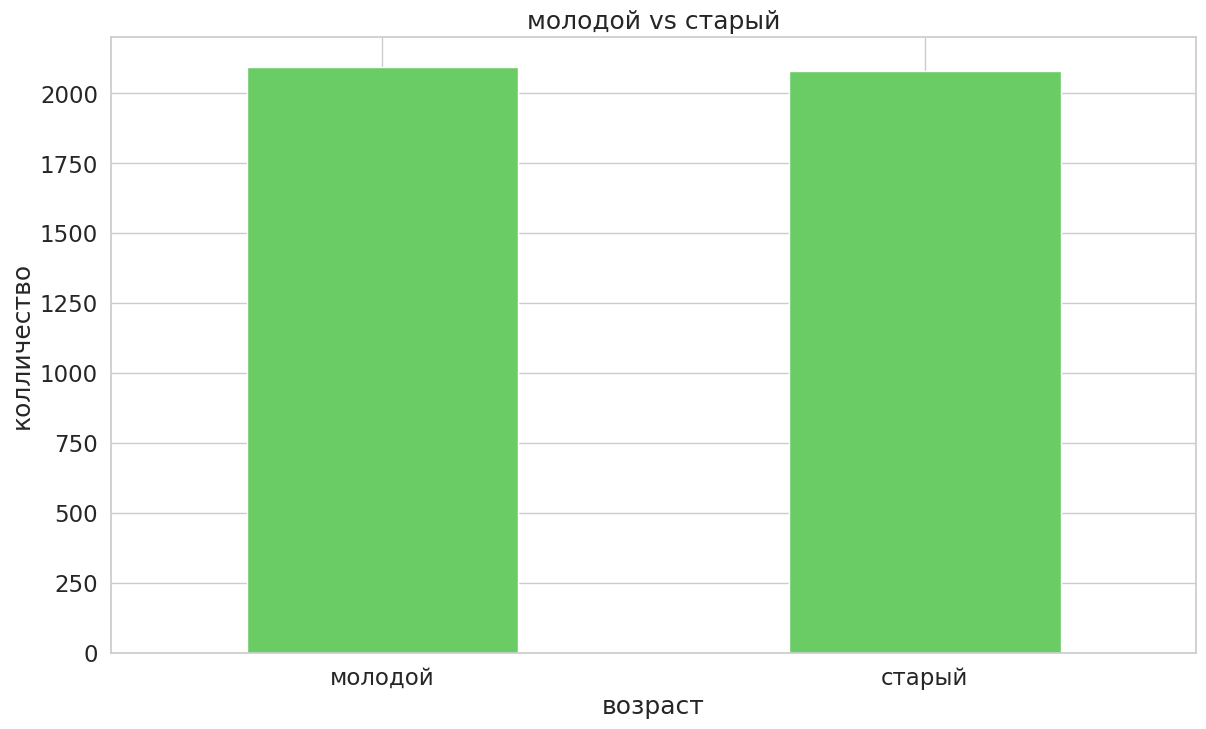

In [11]:
count_classes = pd.value_counts(df['AgeGroup'], sort = True)
count_classes.plot(kind = 'bar', rot=0, color="g")
plt.title("молодой vs старый")
plt.xticks(range(2), LABELS)
plt.xlabel("возраст")
plt.ylabel("колличество");

In [14]:

fraudsDF = df[df.AgeGroup== 1]
normalDF = df[df.AgeGroup== 0]

In [15]:
fraudsDF.shape

(2081, 10)

In [16]:
normalDF.shape

(2096, 10)

In [27]:
fraudsDF.Length.describe()

,Length
count,2081.000000
mean,0.586060
std,0.084226
min,0.290000
25%,0.530000
50%,0.595000
75%,0.645000
max,0.815000


In [28]:
normalDF.Length.describe()

,Length
count,2096.000000
mean,0.462369
std,0.118656
min,0.075000
25%,0.380000
50%,0.470000
75%,0.555000
max,0.745000


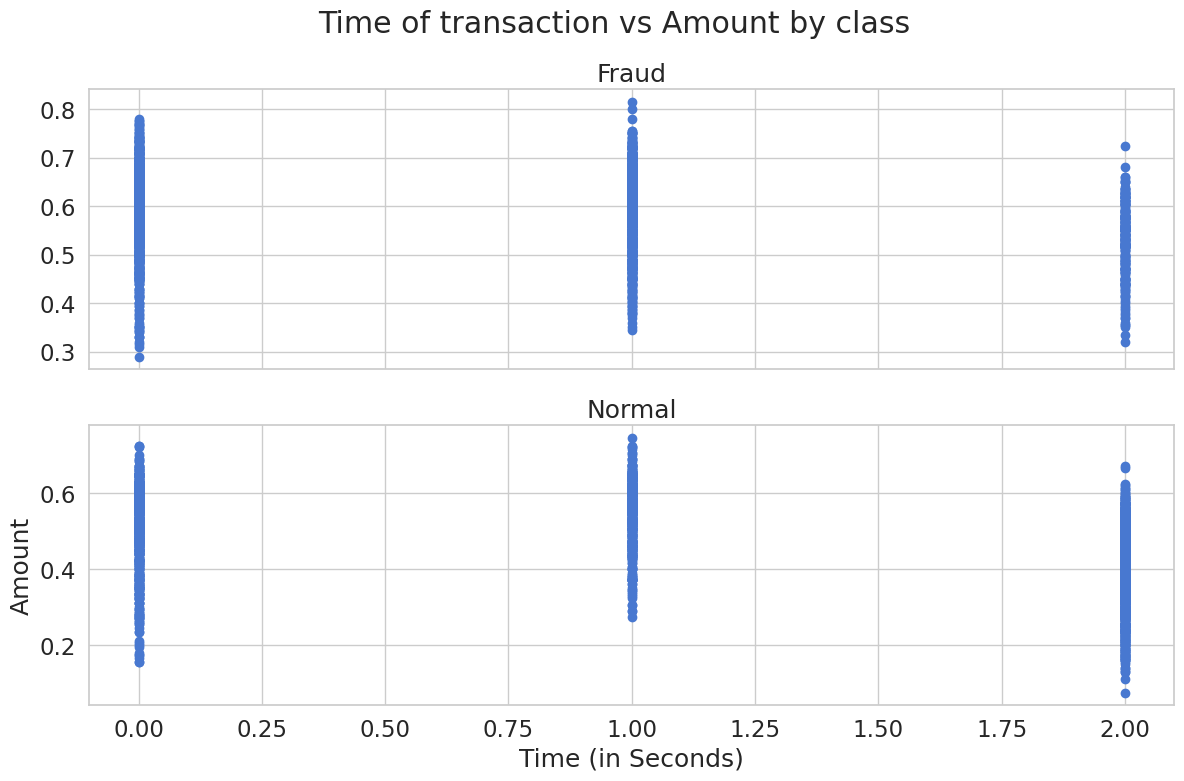

In [30]:
f, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
f.suptitle('Time of transaction vs Amount by class')

ax1.scatter(fraudsDF.Sex, fraudsDF.Length)
ax1.set_title('Fraud')

ax2.scatter(normalDF.Sex, normalDF.Length)
ax2.set_title('Normal')

plt.xlabel('Time (in Seconds)')
plt.ylabel('Amount')
plt.show()

In [32]:
transactionData=df

In [33]:
X_train, X_test = train_test_split(transactionData, test_size=0.2, random_state=RANDOM_SEED)
X_train = X_train[X_train.AgeGroup == 0]
X_train = X_train.drop(['AgeGroup'], axis=1)
#print(type(X_train))
y_test = X_test['AgeGroup']
X_test = X_test.drop(['AgeGroup'], axis=1)

X_train = X_train.values
#print(type(X_train))
X_test = X_test.values
y_test = y_test.values
print(y_test.size)

836


In [42]:
df.head()

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings,AgeGroup
0,0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15,1
1,0,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7,0
2,1,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9,0
3,0,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10,1
4,2,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7,0


In [51]:
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(9, 14),
            nn.Tanh(),
            nn.Linear(14, 7),
            nn.LeakyReLU(),
            )

        self.decoder = nn.Sequential(
           nn.Linear(7, 7),
           nn.Tanh(),
           nn.Linear(7, 9),
           nn.LeakyReLU()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [52]:
model = Autoencoder().double()
#model = Autoencoder().double().cpu()

In [53]:
num_epochs = 100   # сколько эпох будем обучать. Результаты обучения на одной эпохе используются как начальные для следующей.
minibatch_size = 32
learning_rate = 1e-3

In [54]:
train_loader = data_utils.DataLoader(X_train, batch_size=minibatch_size, shuffle=True)

In [55]:
#test = data_utils.TensorDataset(torch.from_numpy(X_test).double(),torch.from_numpy(y_test).double())
#test_loader = data_utils.DataLoader(test, batch_size=minibatch_size, shuffle=True)
test_loader = data_utils.DataLoader(X_test, batch_size=1, shuffle=False)

In [56]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(
model.parameters(), lr=learning_rate, weight_decay=10e-05)

In [57]:
history = {}
history['train_loss'] = []
history['test_loss'] = []

In [58]:
for epoch in range(num_epochs):
    h = np.array([])
    for data in train_loader:
        #print(type(data))
        #data = Variable(data).cpu()
        #print(type(data))
        # ===================forward=====================
        output = model(data)
        loss = criterion(output, data)
        h = np.append(h, loss.item())

        # ===================backward====================
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    # ===================log========================
    mean_loss = np.mean(h)
    print('epoch [{}/{}], loss:{:.4f}'
          .format(epoch + 1, num_epochs, mean_loss))
    history['train_loss'].append(mean_loss)


epoch [1/100], loss:6.1862
epoch [2/100], loss:4.8353
epoch [3/100], loss:3.8851
epoch [4/100], loss:3.2541
epoch [5/100], loss:2.7756
epoch [6/100], loss:2.3721
epoch [7/100], loss:2.0289
epoch [8/100], loss:1.7385
epoch [9/100], loss:1.4900
epoch [10/100], loss:1.2806
epoch [11/100], loss:1.1017
epoch [12/100], loss:0.9529
epoch [13/100], loss:0.8235
epoch [14/100], loss:0.7245
epoch [15/100], loss:0.6380
epoch [16/100], loss:0.5688
epoch [17/100], loss:0.5129
epoch [18/100], loss:0.4674
epoch [19/100], loss:0.4335
epoch [20/100], loss:0.4034
epoch [21/100], loss:0.3822
epoch [22/100], loss:0.3678
epoch [23/100], loss:0.3553
epoch [24/100], loss:0.3436
epoch [25/100], loss:0.3370
epoch [26/100], loss:0.3187
epoch [27/100], loss:0.2636
epoch [28/100], loss:0.2350
epoch [29/100], loss:0.2154
epoch [30/100], loss:0.1950
epoch [31/100], loss:0.1752
epoch [32/100], loss:0.1549
epoch [33/100], loss:0.1378
epoch [34/100], loss:0.1256
epoch [35/100], loss:0.1145
epoch [36/100], loss:0.1048
e

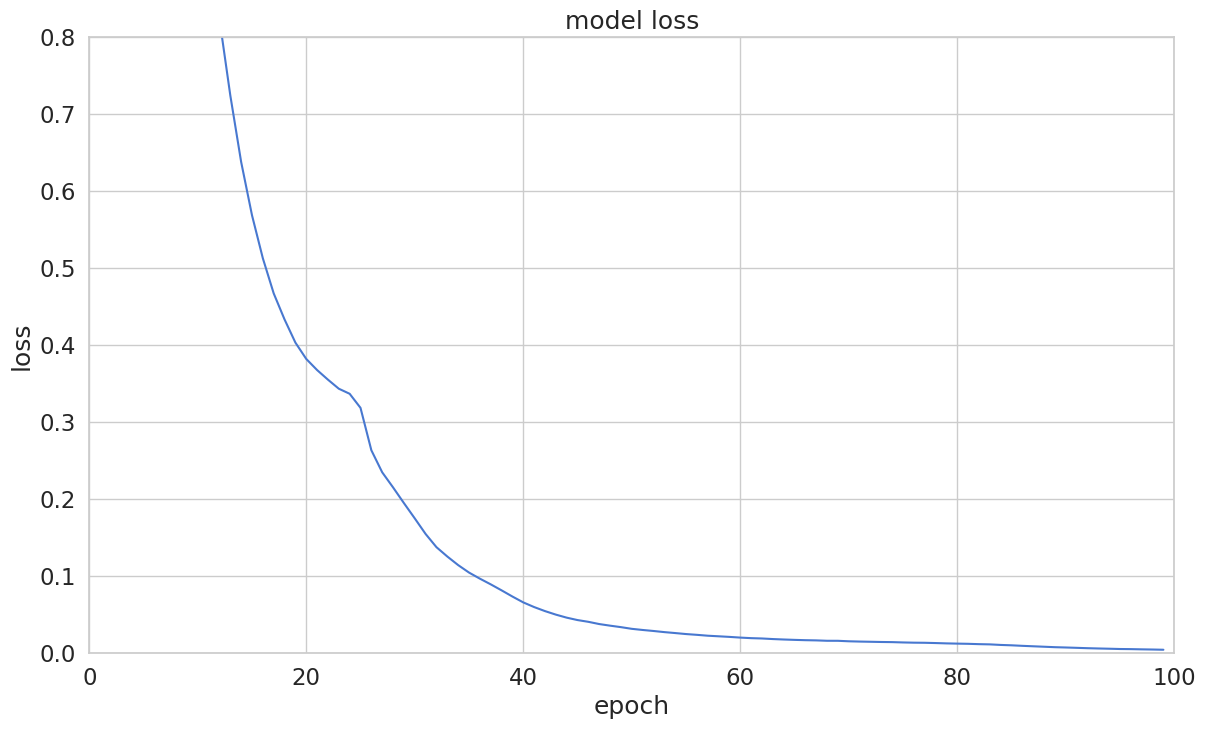

In [60]:
#history['train_loss']
#plt.plot(range(num_epochs),history['train_loss'],'ro',linewidth=2.0)
plt.plot(history['train_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.axis([0,100,0,0.80])
#plt.legend(['train', 'test'], loc='upper right');
plt.show()

In [61]:
pred_losses = {'pred_loss' : []}
model.eval()
with torch.no_grad():
   # test_loss = 0
    for data in test_loader:
        inputs = data
        # print(inputs)
        outputs = model(inputs)
        loss = criterion(outputs, inputs).data.item()
        #print(loss)
        pred_losses['pred_loss'].append(loss)
        #pred_losses = model([y_test.size, y_test])
reconstructionErrorDF = pd.DataFrame(pred_losses)
reconstructionErrorDF['AgeGroup'] = y_test

In [62]:
reconstructionErrorDF.describe()

,pred_loss,AgeGroup
count,836.000000,836.000000
mean,0.754633,0.496411
std,2.280480,0.500286
min,0.000180,0.000000
25%,0.002706,0.000000
50%,0.025438,0.000000
75%,0.210790,1.000000
max,18.333327,1.000000


In [63]:
reconstructionErrorDF.describe()

,pred_loss,AgeGroup
count,836.000000,836.000000
mean,0.754633,0.496411
std,2.280480,0.500286
min,0.000180,0.000000
25%,0.002706,0.000000
50%,0.025438,0.000000
75%,0.210790,1.000000
max,18.333327,1.000000


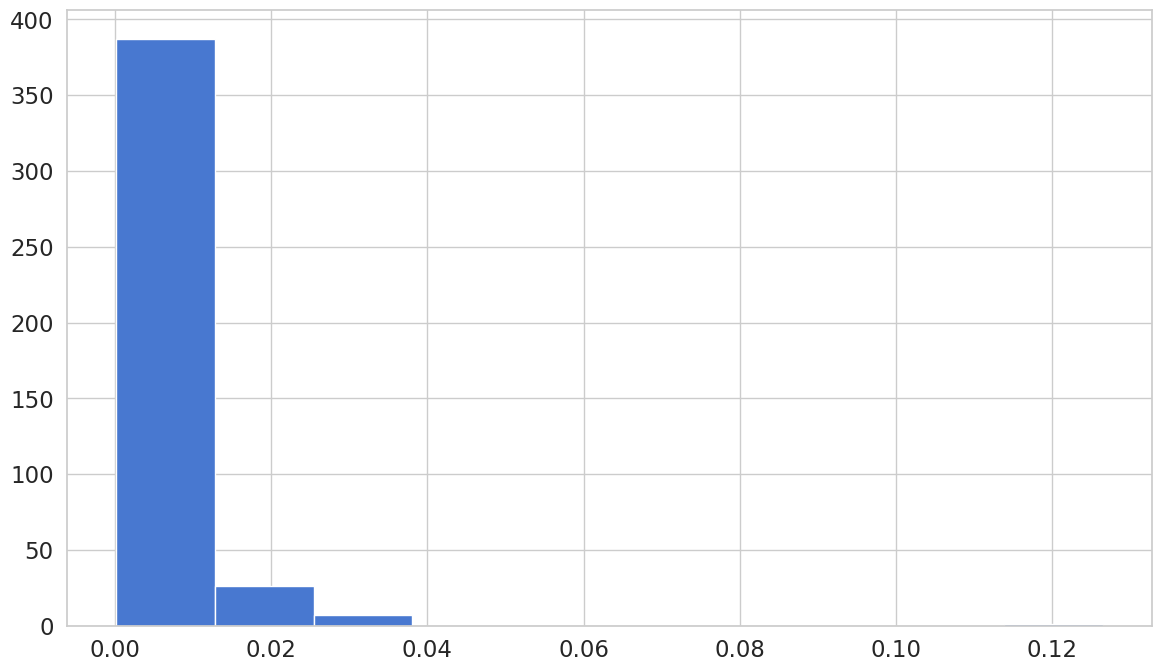

In [64]:
fig = plt.figure()
ax = fig.add_subplot(111)
normal_error_df = reconstructionErrorDF[(reconstructionErrorDF['AgeGroup']== 0) & (reconstructionErrorDF['pred_loss'] < 10)]
_ = ax.hist(normal_error_df.pred_loss.values, bins=10)

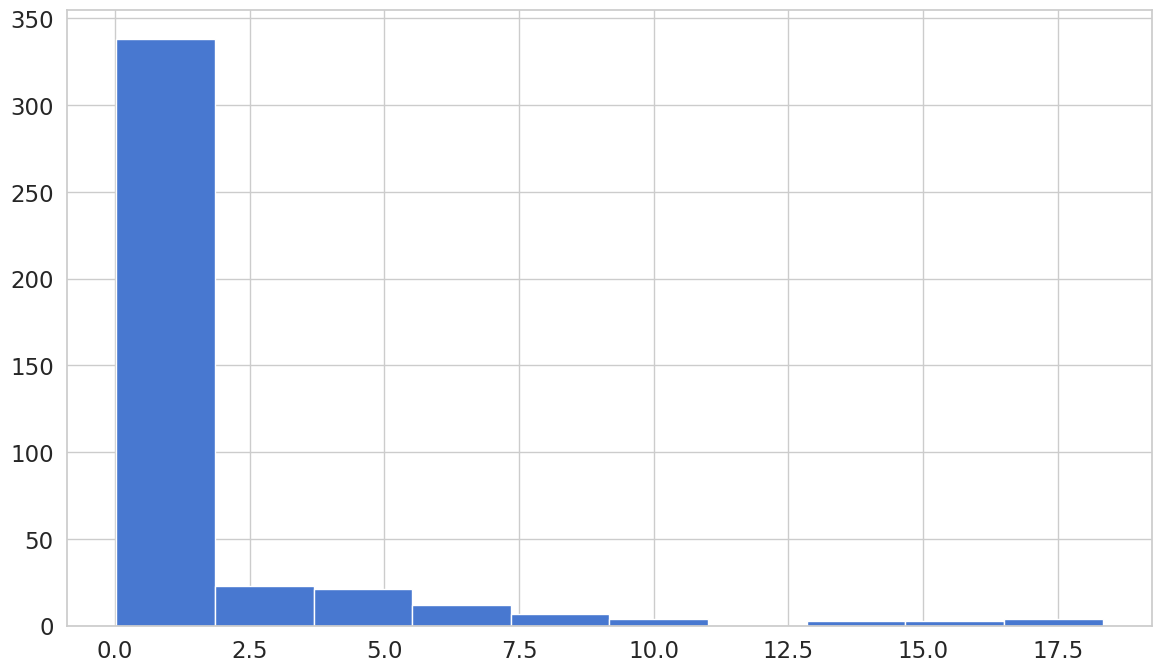

In [65]:
fig = plt.figure()
ax = fig.add_subplot(111)
fraud_error_df = reconstructionErrorDF[(reconstructionErrorDF['AgeGroup']== 1) ]
_ = ax.hist(fraud_error_df.pred_loss.values, bins=10)

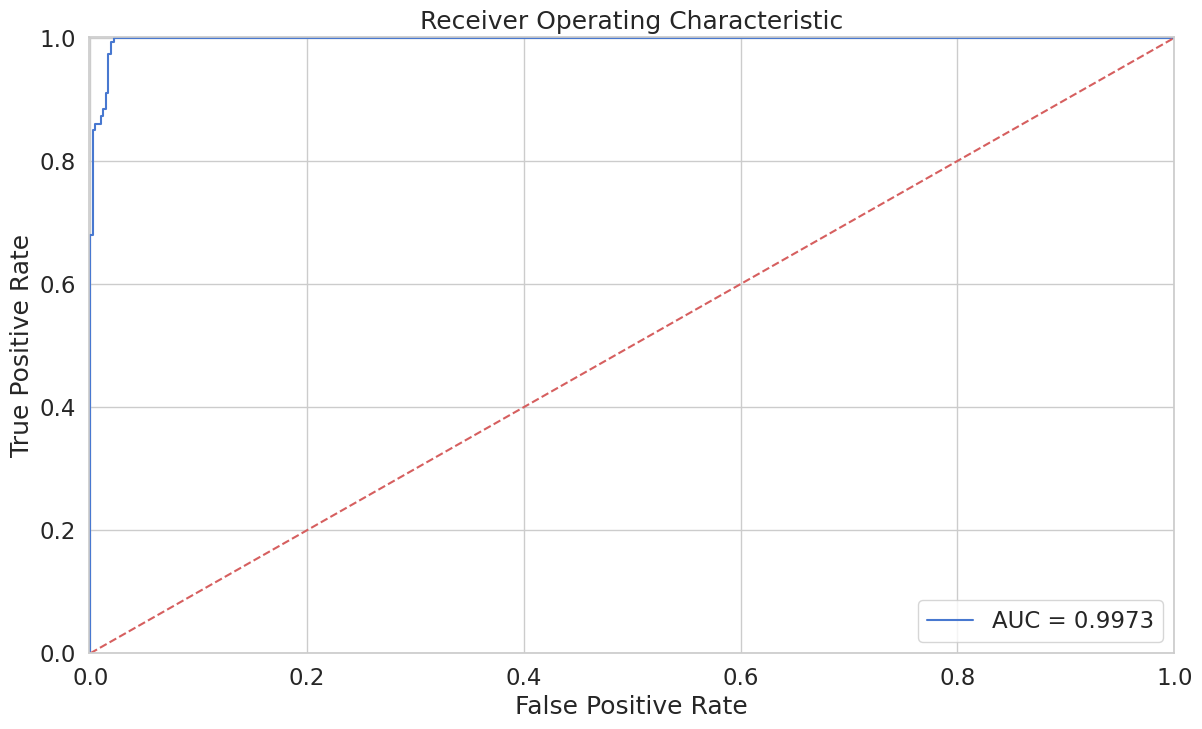

In [67]:
fpr, tpr, thresholds = roc_curve(reconstructionErrorDF.AgeGroup, reconstructionErrorDF.pred_loss)
roc_auc = auc(fpr, tpr)

plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, label='AUC = %0.4f'% roc_auc)
plt.legend(loc='lower right')
plt.plot([0,1],[0,1],'r--')
plt.xlim([-0.001, 1])
plt.ylim([0, 1.001])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show();

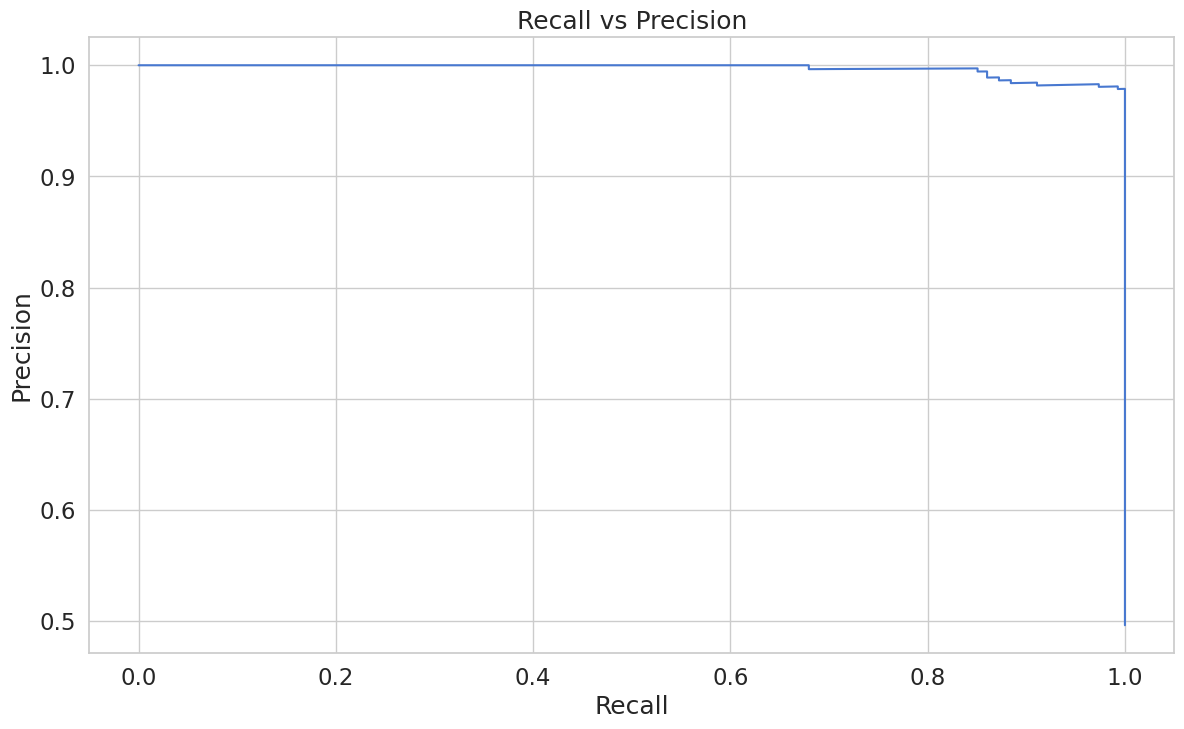

In [68]:
precision, recall, th = precision_recall_curve(reconstructionErrorDF.AgeGroup, reconstructionErrorDF.pred_loss)
plt.plot(recall, precision, 'b', label='Precision-Recall curve')
plt.title('Recall vs Precision')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.show()

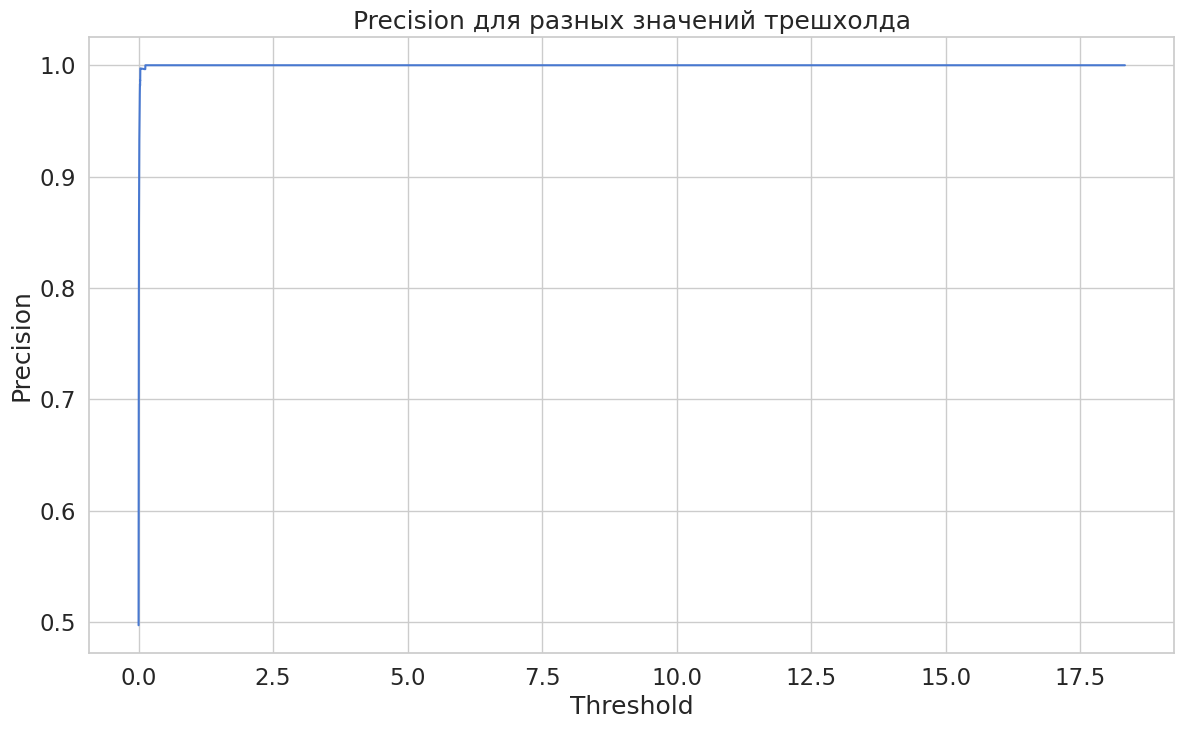

In [69]:
plt.plot(th, precision[1:], 'b', label='Threshold-Precision curve')
plt.title('Precision для разных значений трешхолда')
plt.xlabel('Threshold')
plt.ylabel('Precision')
plt.show()

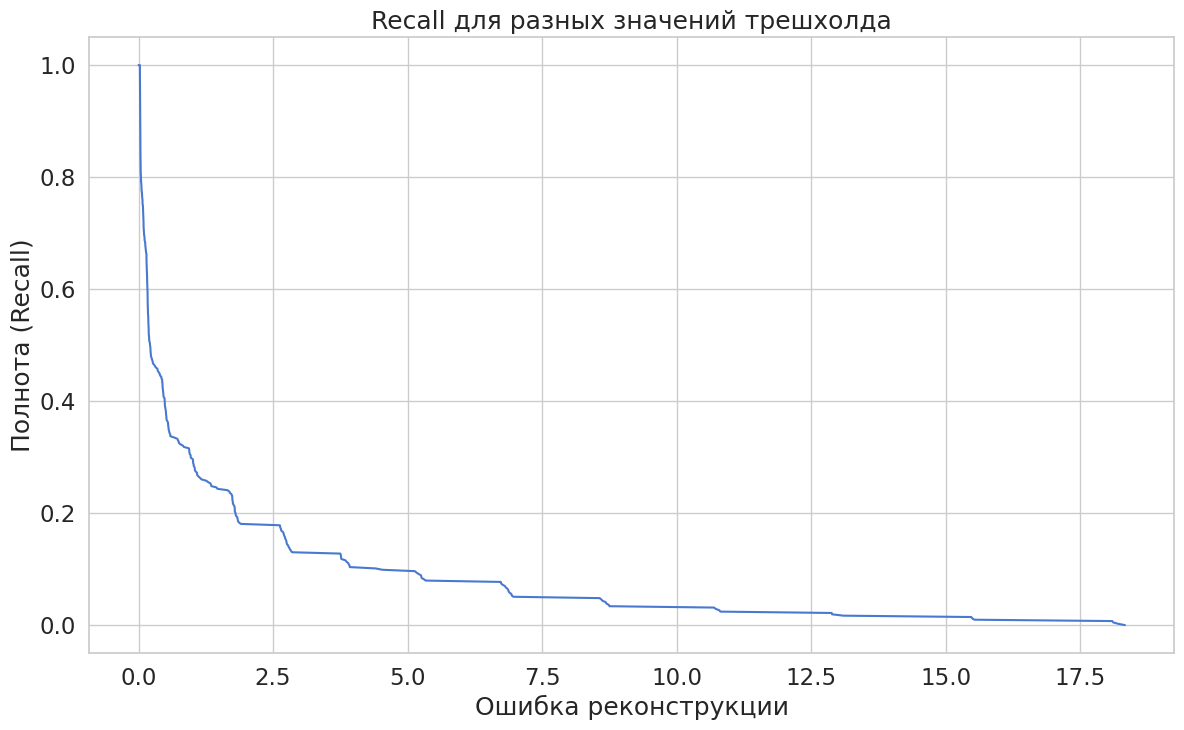

In [70]:
plt.plot(th, recall[1:], 'b', label='Threshold-Recall curve')
plt.title('Recall для разных значений трешхолда')
plt.xlabel('Ошибка реконструкции')
plt.ylabel('Полнота (Recall)')
plt.show()

In [71]:
threshold = 2.9

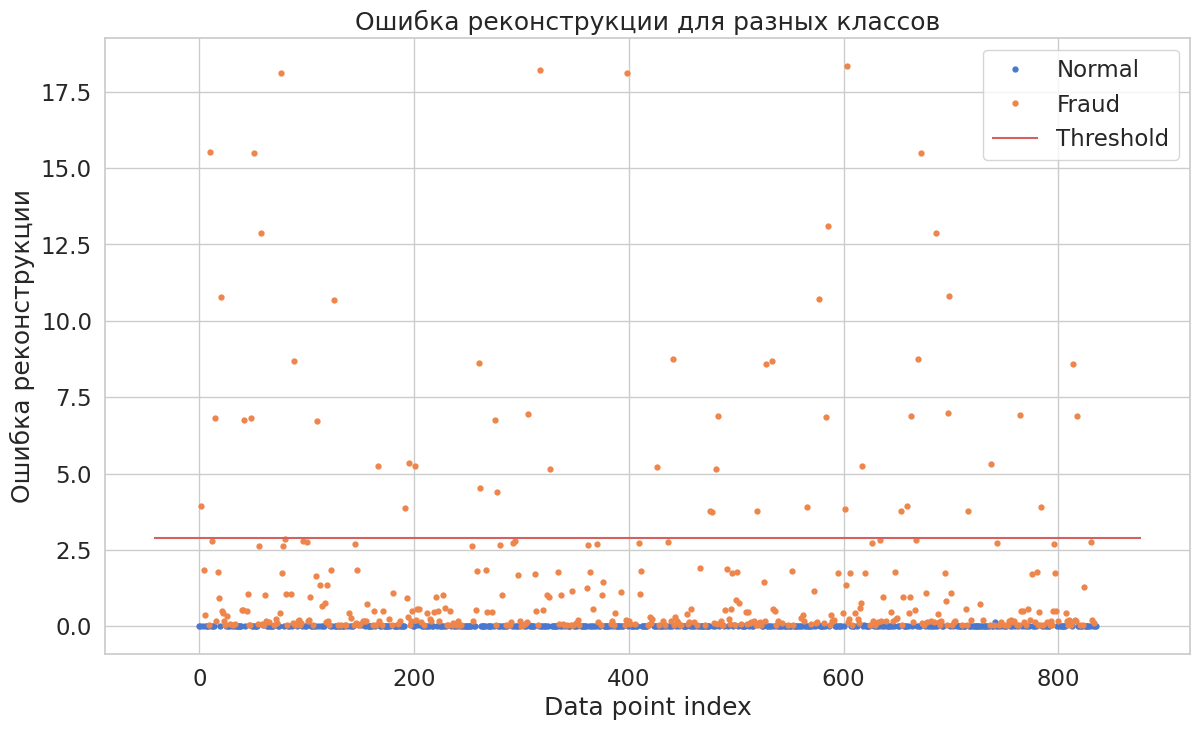

In [72]:
groups = reconstructionErrorDF.groupby('AgeGroup')
fig, ax = plt.subplots()

for name, group in groups:
    ax.plot(group.index, group.pred_loss, marker='o', ms=3.5, linestyle='',
            label= "Fraud" if name == 1 else "Normal")
ax.hlines(threshold, ax.get_xlim()[0], ax.get_xlim()[1], colors="r", zorder=100, label='Threshold')
ax.legend()
plt.title("Ошибка реконструкции для разных классов")
plt.ylabel("Ошибка реконструкции")
plt.xlabel("Data point index")
plt.show();

/tmp/ipykernel_3610/2839478504.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=plt.cm.get_cmap('Blues'));


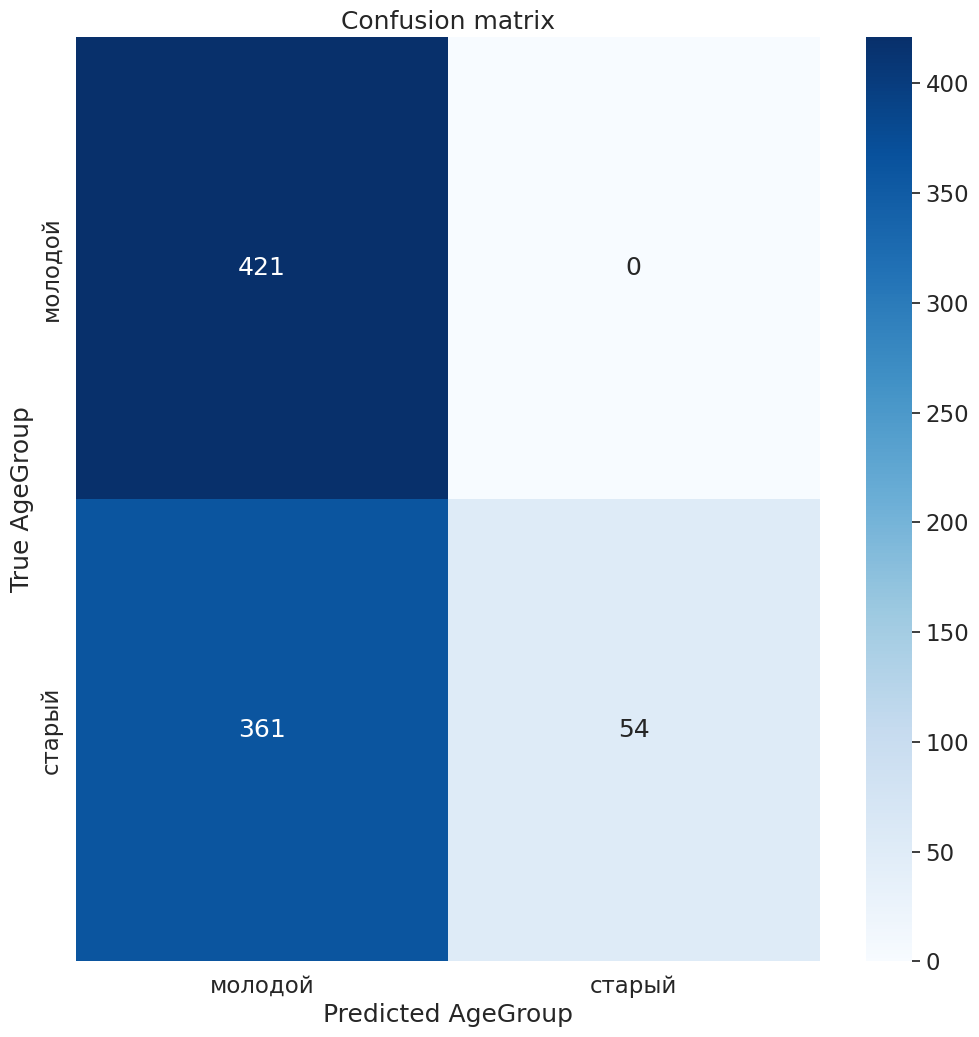

In [74]:
y_pred = [1 if e > threshold else 0 for e in reconstructionErrorDF.pred_loss.values]
conf_matrix = confusion_matrix(reconstructionErrorDF.AgeGroup, y_pred)
plt.figure(figsize=(12, 12))
sns.heatmap(conf_matrix, xticklabels=LABELS, yticklabels=LABELS, annot=True, fmt="d",
            cmap=plt.cm.get_cmap('Blues'));
plt.title("Confusion matrix")
plt.ylabel('True AgeGroup')
plt.xlabel('Predicted AgeGroup')
plt.show()